# Linear and Regularized Regression

**Goal**: Predict a continuous target (a number) using features.

We will use a dataset, split it into training data and testing data, and compare various models including Linear Regression, Lasso, Ridge, and Gradient Boosting.

### 1. Load the Dataset

We will use the California Housing dataset. It has features like median income (MedInc) and average rooms (AveRooms) to predict the median house value.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()
print("Features:", data.feature_names)

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


### 2. Brief Exploration

Let's put the data into a pandas DataFrame.

In [17]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### 3. The Scale Problem (Why Normalize?)

Look at the features below. Some are tiny (MedInc ranges 0.5-15), while others are massive (Population ranges 3-35682). If we don't scale these, regularized models get very confused!

In [18]:
df[['MedInc', 'AveRooms', 'Population']].describe()

,MedInc,AveRooms,Population
count,20640.000000,20640.000000,20640.000000
mean,3.870671,5.429000,1425.476744
std,1.899822,2.474173,1132.462122
min,0.499900,0.846154,3.000000
25%,2.563400,4.440716,787.000000
50%,3.534800,5.229129,1166.000000
75%,4.743250,6.052381,1725.000000
max,15.000100,141.909091,35682.000000


Let's visualize the scale difference between `MedInc` and `Population`:

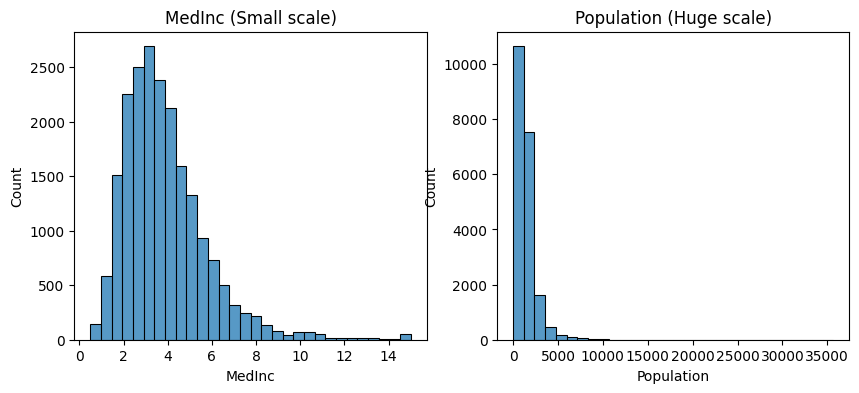

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df['MedInc'], ax=ax[0], bins=30).set(title='MedInc (Small scale)')
sns.histplot(df['Population'], ax=ax[1], bins=30).set(title='Population (Huge scale)')
plt.show()

### 4. Split into Features (X) and Target (y)

In [20]:
X = df.drop(columns=['target'])
y = df['target']

### 5. Train/Test Split

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (16512, 8)
Test size: (4128, 8)


### 6. Applying Normalization with StandardScaler

We scale the features so they have a mean of 0 and standard deviation of 1. **Crucial rule**: Always `fit_transform` on the training set, and only `transform` on the test set to avoid data leakage!

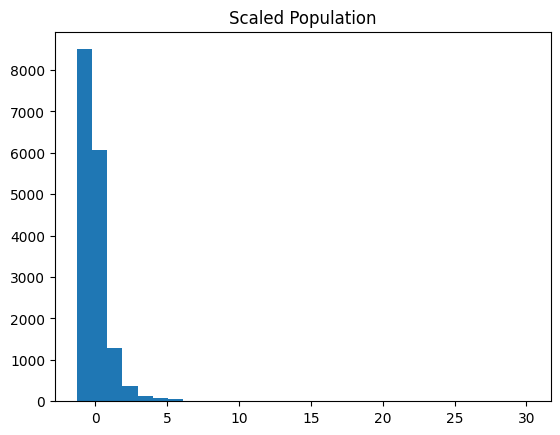

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Let's see the scaled training data for Population
plt.hist(X_train_scaled[:, data.feature_names.index('Population')], bins=30)
plt.title('Scaled Population')
plt.show()

### 7. Baseline Model: Linear Regression

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)

y_pred_test_lr = model_lr.predict(X_test_scaled)
r2_lr = r2_score(y_test, y_pred_test_lr)
print("LR Test R2:", r2_lr)

LR Test R2: 0.5757877060324508


Let's visualize Actual vs Predicted to see our model quality!

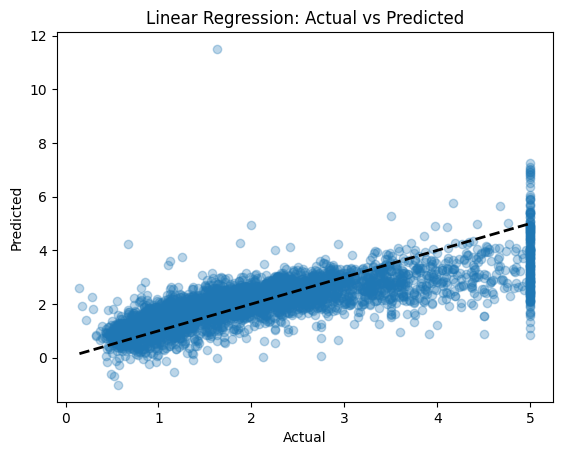

In [24]:
plt.scatter(y_test, y_pred_test_lr, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Linear Regression: Actual vs Predicted')
plt.show()

### 8. Lasso Regression (L1 Regularization)

Lasso (L1) tries to shrink coefficients, sometimes setting them exactly to 0. Great for feature selection!

In [25]:
from sklearn.linear_model import Lasso

model_lasso = Lasso(alpha=0.1, random_state=42)
model_lasso.fit(X_train_scaled, y_train)

y_pred_test_las = model_lasso.predict(X_test_scaled)
r2_las = r2_score(y_test, y_pred_test_las)
print("Lasso Test R2:", r2_las)

Lasso Test R2: 0.48136113250290735


### 9. Ridge Regression (L2 Regularization)

Ridge (L2) prevents coefficients from getting too large but rarely forces them strictly to zero.

In [26]:
from sklearn.linear_model import Ridge

model_ridge = Ridge(alpha=10.0, random_state=42)
model_ridge.fit(X_train_scaled, y_train)

y_pred_test_rdg = model_ridge.predict(X_test_scaled)
r2_rdg = r2_score(y_test, y_pred_test_rdg)
print("Ridge Test R2:", r2_rdg)

Ridge Test R2: 0.576059903284837


### 10. Comparing Coefficients

Let's visualize what the regularizations did to our features:

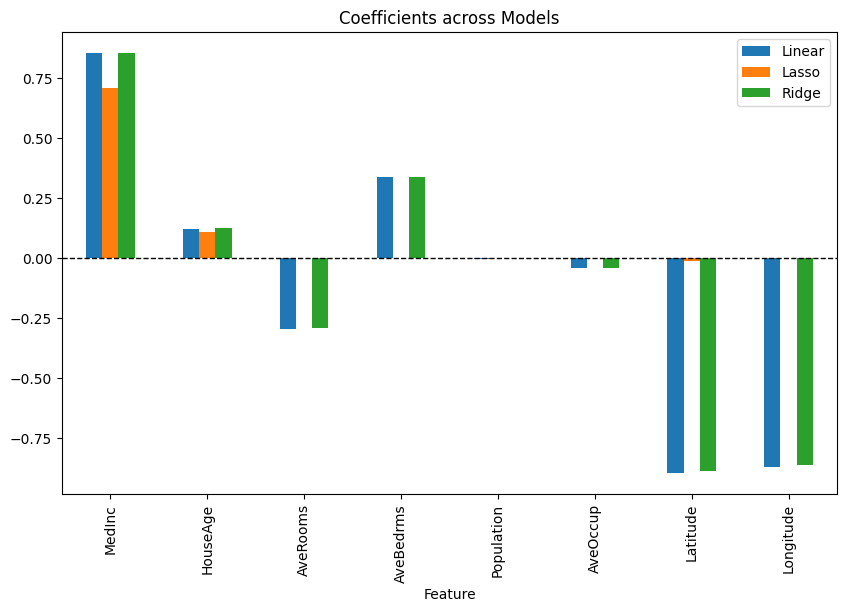

In [27]:
coef_df = pd.DataFrame({
    'Feature': data.feature_names,
    'Linear': model_lr.coef_,
    'Lasso': model_lasso.coef_,
    'Ridge': model_ridge.coef_
})

coef_df.set_index('Feature').plot(kind='bar', figsize=(10,6))
plt.title('Coefficients across Models')
plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.show()

### 11. Gradient Boosting Regressor (Ensemble)

Let's try a powerful tree-based ensemble method to see if it performs better than simple regularized linear models!

In [28]:
from sklearn.ensemble import GradientBoostingRegressor

model_gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
model_gb.fit(X_train_scaled, y_train)

y_pred_test_gb = model_gb.predict(X_test_scaled)
r2_gb = r2_score(y_test, y_pred_test_gb)
print("Gradient Boosting Test R2:", r2_gb)

Gradient Boosting Test R2: 0.7756433164710084


### 12. Summary Comparison

Let's summarize everything in a neat table.

In [29]:
results_reg = pd.DataFrame({
    'Model': ['Linear Regression', 'Lasso (L1)', 'Ridge (L2)', 'Gradient Boosting'],
    'Test R2': [r2_lr, r2_las, r2_rdg, r2_gb],
    'Type': ['Linear', 'Linear (Sparse)', 'Linear (Shrinkage)', 'Tree Ensemble']
})
results_reg.sort_values('Test R2', ascending=False)

,Model,Test R2,Type
3,Gradient Boosting,0.775643,Tree Ensemble
2,Ridge (L2),0.576060,Linear (Shrinkage)
0,Linear Regression,0.575788,Linear
1,Lasso (L1),0.481361,Linear (Sparse)


### Try It Yourself!

**Exercises:**
1. Try different `alpha` values in Lasso and Ridge and see how the coefficient bar chart changes.
2. Change the `n_estimators` in Gradient Boosting.